# 4.0 — Clustering: K-Means, DBSCAN, Jerárquico y GMM
**Proyecto:** Segmentación de Clientes — E-commerce de Ferretería
**Autor:** Ian Gallego | Politécnico Malvinas Argentinas | 2026

---
Este es el **notebook principal del proyecto**. Aplica los 4 algoritmos de clustering
sobre las features RFM escaladas, compara métricas internas y elige el modelo de
producción. La interpretación comercial de los segmentos vive en el notebook 5.

### Decisiones metodológicas 
| Decisión | Valor |
|----------|-------|
| Features de clustering | `recency`, `frequency`, `monetary_log` (RFM puro) |
| Features de caracterización | `ticket_promedio`, `diversidad_categorias`, `antiguedad` (no entran al modelo) |
| Escalado | `StandardScaler` sobre las features de clustering |
| PCA | Solo para visualización 2D — reportamos varianza explicada |
| Modelo de producción | K-Means (simple, interpretable, con `.predict()` nativo) |


## 1. Carga y escalado

In [1]:
# Setup: agregar el root del proyecto al sys.path para importar segmentacion/
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

from segmentacion.features import FEATURES_CLUSTERING, escalar_features
from segmentacion.plots import (metodo_codo, grafico_k_distancia, dendrograma,
                                 scatter_clusters_2d, comparar_metricas,
                                 heatmap_concordancia, silhouette_plot)
from segmentacion.modeling.train import (entrenar_kmeans, entrenar_dbscan,
                                          entrenar_jerarquico, entrenar_gmm, evaluar,
                                          sanity_check_tamanos, guardar_modelo)
from segmentacion.config import PROCESSED_DATA_DIR, MODELS_DIR, FIGURES_DIR

clientes = pd.read_parquet(PROCESSED_DATA_DIR / 'clientes_rfm.parquet')
print(f'Clientes: {len(clientes):,}')
print(f'FEATURES_CLUSTERING = {FEATURES_CLUSTERING}')
clientes[FEATURES_CLUSTERING].describe().round(2)

2026-06-01 22:36:08.007 | INFO     | segmentacion.config:<module>:11 - PROJ_ROOT path is: F:\TrabajoFinalApAut


Clientes: 999
FEATURES_CLUSTERING = ['recency', 'frequency', 'monetary_log']


,recency,frequency,monetary_log
count,999.00,999.00,999.00
mean,237.96,10.14,13.02
std,201.67,10.36,1.78
min,0.00,1.00,8.26
25%,49.50,3.00,11.94
50%,198.00,7.00,13.00
75%,397.50,14.00,13.97
max,711.00,65.00,17.42


In [2]:
X, scaler = escalar_features(clientes, FEATURES_CLUSTERING)
print(f'X shape: {X.shape}  |  media~0, std~1 por columna')
print(pd.DataFrame(X, columns=FEATURES_CLUSTERING).describe().round(3).iloc[1:3])

2026-06-01 22:36:08.313 | INFO     | segmentacion.features:escalar_features:102 - Features escaladas: ['recency', 'frequency', 'monetary_log'] -> shape (999, 3)
X shape: (999, 3)  |  media~0, std~1 por columna
      recency  frequency  monetary_log
mean    0.000      0.000        -0.000
std     1.001      1.001         1.001


## 2. K-Means — método del codo + Silhouette por K

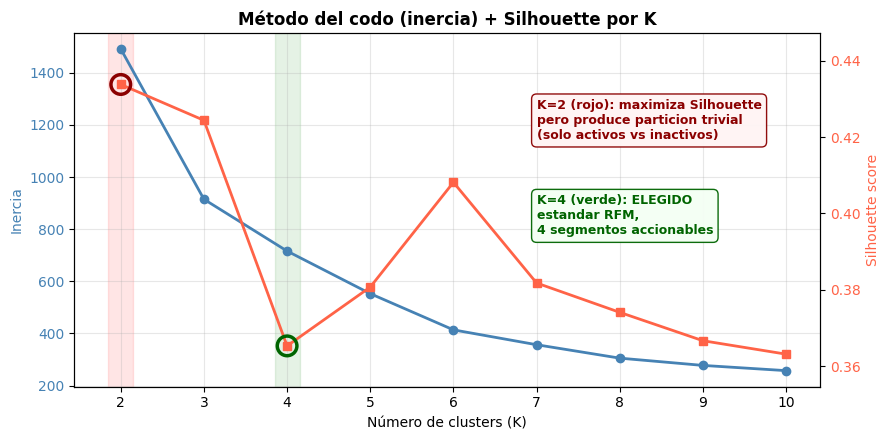

K  | Inercia    | Silhouette
 2 |   1491.43  | 0.4338  <- K=2 max Silhouette
 3 |    914.84  | 0.4244
 4 |    716.14  | 0.3653  <- K=4 ELEGIDO
 5 |    552.80  | 0.3807
 6 |    413.93  | 0.4082
 7 |    356.92  | 0.3818
 8 |    305.43  | 0.3741
 9 |    277.57  | 0.3666
10 |    257.53  | 0.3631


In [3]:
fig, inercias, silhouettes = metodo_codo(
    X, k_range=range(2, 11),
    output=None
)

# Mejoras de legibilidad:
# - Bandas verticales suaves en K=2 (rojo) y K=4 (verde) en lugar de flechas largas
# - Cajas de texto en la parte alta del grafico, lejos de las curvas
# - Marcadores grandes circulares en los puntos clave
ax1, ax2 = fig.axes

# Bandas verticales discretas
ax1.axvspan(1.85, 2.15, color='red',   alpha=0.10, zorder=0)
ax1.axvspan(3.85, 4.15, color='green', alpha=0.10, zorder=0)

# Marcadores destacados en los puntos K=2 y K=4 sobre la curva de Silhouette
ax2.scatter([2], [silhouettes[0]], s=200, facecolors='none',
            edgecolors='darkred', linewidths=2.5, zorder=10)
ax2.scatter([4], [silhouettes[2]], s=200, facecolors='none',
            edgecolors='darkgreen', linewidths=2.5, zorder=10)

# Cajas de texto explicativas en zonas SIN curvas (parte superior del grafico)
# Coordenadas en data: usamos K=7-10 que esta vacio salvo por las colas de las curvas
ax2.text(
    7.0, 0.43,
    'K=2 (rojo): maximiza Silhouette\npero produce particion trivial\n(solo activos vs inactivos)',
    fontsize=9, color='darkred', fontweight='bold',
    ha='left', va='top',
    bbox=dict(boxstyle='round,pad=0.4',
              facecolor='#FFF4F4', edgecolor='darkred', alpha=0.95),
)
ax2.text(
    7.0, 0.405,
    'K=4 (verde): ELEGIDO\nestandar RFM,\n4 segmentos accionables',
    fontsize=9, color='darkgreen', fontweight='bold',
    ha='left', va='top',
    bbox=dict(boxstyle='round,pad=0.4',
              facecolor='#F4FFF4', edgecolor='darkgreen', alpha=0.95),
)

# Expandimos un poco el eje de Silhouette para que las cajas no queden cortadas
y_min, y_max = ax2.get_ylim()
ax2.set_ylim(y_min - 0.005, y_max + 0.01)

fig.tight_layout()
from segmentacion.config import FIGURES_DIR
fig.savefig(FIGURES_DIR / 'nb4_codo_silhouette.png', dpi=120, bbox_inches='tight')
import matplotlib.pyplot as plt
plt.show()

print('K  | Inercia    | Silhouette')
for k, i, s in zip(range(2, 11), inercias, silhouettes):
    marca = ''
    if k == 2: marca = '  <- K=2 max Silhouette'
    elif k == 4: marca = '  <- K=4 ELEGIDO'
    print(f'{k:>2} | {i:>9.2f}  | {s:.4f}{marca}')

In [4]:
# Justificacion de K
# El K que MAXIMIZA Silhouette es K=2, pero produce solo una particion trivial
# (compradores activos vs inactivos), insuficiente para personalizacion de marketing.
# Elegimos K=4 que es el estandar RFM, mantiene Silhouette aceptable y permite
# distinguir los 4 segmentos clasicos: Campeones, Leales, En Riesgo, Perdidos.

K_max_silhouette = int(np.argmax(silhouettes)) + 2
K_OPTIMO = 4  # decision deliberada por criterio de negocio
print(f"K que maximiza Silhouette: {K_max_silhouette}  (silhouette={max(silhouettes):.4f})")
print(f"K elegido para el modelo final: {K_OPTIMO}  (silhouette={silhouettes[K_OPTIMO-2]:.4f})")
print("Justificacion: K=2 es trivial para marketing, K=4 es estandar RFM.")

modelo_km, labels_km = entrenar_kmeans(X, k=K_OPTIMO)
sanity_check_tamanos(labels_km)

K que maximiza Silhouette: 2  (silhouette=0.4338)
K elegido para el modelo final: 4  (silhouette=0.3653)
Justificacion: K=2 es trivial para marketing, K=4 es estandar RFM.
2026-06-01 22:36:11.069 | INFO     | segmentacion.modeling.train:entrenar_kmeans:22 - K-Means entrenado: K=4, inercia=716.14
2026-06-01 22:36:11.069 | INFO     | segmentacion.modeling.train:sanity_check_tamanos:105 - Tamaños por cluster:
2026-06-01 22:36:11.070 | INFO     | segmentacion.modeling.train:sanity_check_tamanos:110 -   Cluster 0: 322 (32.2 %)
2026-06-01 22:36:11.070 | INFO     | segmentacion.modeling.train:sanity_check_tamanos:110 -   Cluster 1: 154 (15.4 %)
2026-06-01 22:36:11.070 | INFO     | segmentacion.modeling.train:sanity_check_tamanos:110 -   Cluster 2: 217 (21.7 %)
2026-06-01 22:36:11.070 | INFO     | segmentacion.modeling.train:sanity_check_tamanos:110 -   Cluster 3: 306 (30.6 %)


## 3. DBSCAN — gráfico k-distancia → elección de eps
Con datos RFM continuos (gradiente de clientes), DBSCAN puede tender a un cluster
dominante + ruido. Eso es un **resultado válido** (no hay grupos densos naturales),
se reporta como tal. El eps se elige en el codo del gráfico k-distancia (k=5).

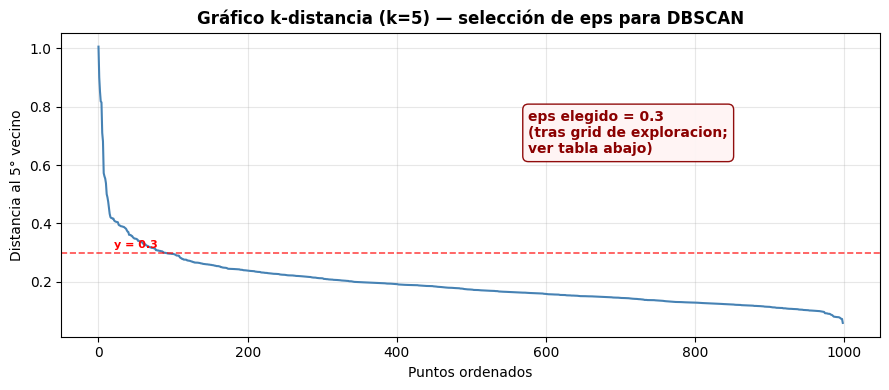

Exploracion de eps (min_samples=5):
  eps  | n_clusters | n_outliers | pct_outliers
   0.2 |     10     |     199    |  19.9 pct
  0.25 |     10     |      73    |   7.3 pct
   0.3 |      5     |      33    |   3.3 pct  <- elegido
  0.35 |      3     |      19    |   1.9 pct
   0.4 |      3     |      11    |   1.1 pct
   0.5 |      2     |       8    |   0.8 pct
   0.7 |      1     |       4    |   0.4 pct
   1.0 |      1     |       0    |   0.0 pct

eps seleccionado: 0.3


In [5]:
fig, dist_ord = grafico_k_distancia(X, k=5, output=None)

# Mejora: la curva cae a casi 0 muy rapido. Ponemos la anotacion en la zona
# alta-derecha que esta totalmente vacia, sin flechas largas.
import numpy as np
ax = fig.axes[0]
EPS_FINAL = 0.3

# Linea horizontal del eps elegido (mas sutil)
ax.axhline(y=EPS_FINAL, color='red', linestyle='--', linewidth=1.2, alpha=0.7)

# Caja de texto en la zona alta-derecha (vacia)
x_max = ax.get_xlim()[1]
y_max = ax.get_ylim()[1]
ax.text(
    x_max * 0.55, y_max * 0.75,
    f'eps elegido = {EPS_FINAL}\n(tras grid de exploracion;\nver tabla abajo)',
    fontsize=10, color='darkred', fontweight='bold',
    ha='left', va='top',
    bbox=dict(boxstyle='round,pad=0.4',
              facecolor='#FFF4F4', edgecolor='darkred', alpha=0.95),
)
# Etiqueta pequena sobre la linea horizontal
ax.text(
    x_max * 0.02, EPS_FINAL + y_max * 0.015,
    f'y = {EPS_FINAL}',
    fontsize=8, color='red', fontweight='bold',
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'nb4_k_distancia.png', dpi=120, bbox_inches='tight')
import matplotlib.pyplot as plt
plt.show()

# Exploramos varios eps en una cuadricula para elegir un valor robusto
from sklearn.cluster import DBSCAN as _DBSCAN
print('Exploracion de eps (min_samples=5):')
print('  eps  | n_clusters | n_outliers | pct_outliers')
for eps_test in [0.2, 0.25, 0.3, 0.35, 0.4, 0.5, 0.7, 1.0]:
    db = _DBSCAN(eps=eps_test, min_samples=5).fit(X)
    n_clu = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
    n_out = int((db.labels_ == -1).sum())
    pct = n_out / len(X) * 100
    marca = '  <- elegido' if eps_test == EPS_FINAL else ''
    print(f'  {eps_test:>4} |     {n_clu:>2}     |    {n_out:>4}    | {pct:>5.1f} pct{marca}')

EPS = EPS_FINAL
print()
print('eps seleccionado:', EPS)

In [6]:
modelo_db, labels_db = entrenar_dbscan(X, eps=EPS, min_samples=5)
sanity_check_tamanos(labels_db)

2026-06-01 22:36:11.412 | INFO     | segmentacion.modeling.train:entrenar_dbscan:33 - DBSCAN entrenado: eps=0.3, min_samples=5, clusters=5, outliers=33
2026-06-01 22:36:11.413 | INFO     | segmentacion.modeling.train:sanity_check_tamanos:105 - Tamaños por cluster:
2026-06-01 22:36:11.413 | INFO     | segmentacion.modeling.train:sanity_check_tamanos:110 -   Outliers: 33 (3.3 %)
2026-06-01 22:36:11.413 | INFO     | segmentacion.modeling.train:sanity_check_tamanos:110 -   Cluster 0: 922 (92.3 %)
2026-06-01 22:36:11.413 | INFO     | segmentacion.modeling.train:sanity_check_tamanos:110 -   Cluster 1: 15 (1.5 %)
2026-06-01 22:36:11.413 | INFO     | segmentacion.modeling.train:sanity_check_tamanos:110 -   Cluster 2: 9 (0.9 %)  WARN (cluster trivial)
2026-06-01 22:36:11.413 | INFO     | segmentacion.modeling.train:sanity_check_tamanos:110 -   Cluster 3: 9 (0.9 %)  WARN (cluster trivial)
2026-06-01 22:36:11.413 | INFO     | segmentacion.modeling.train:sanity_check_tamanos:110 -   Cluster 4: 11 

## 4. Jerárquico Aglomerativo — dendrograma → n° de clusters
Dendrograma truncado a 30 ramas para legibilidad con 999 clientes.
El n° de clusters se elige observando el corte horizontal con mayor 'salto' vertical
(criterio de máxima distancia inter-cluster).

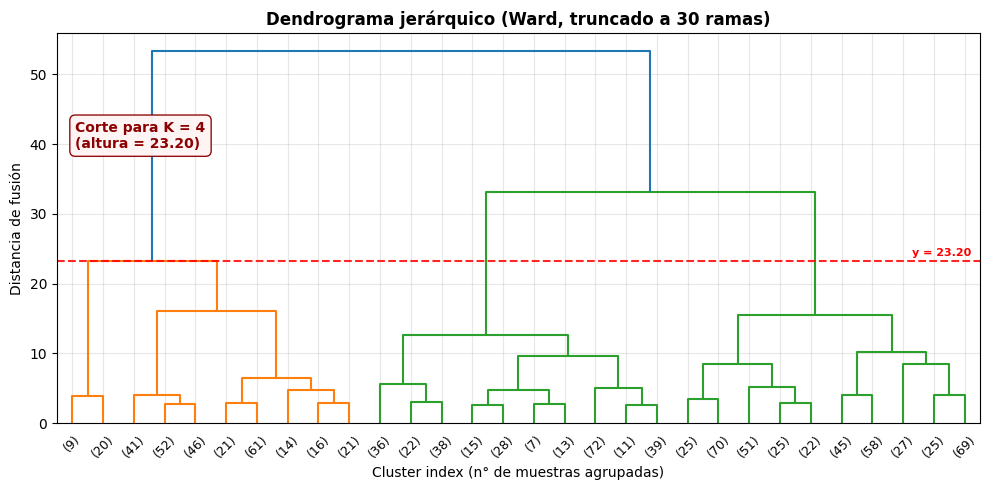

In [7]:
fig = dendrograma(X, output=None, truncate_p=30)
ax = fig.axes[0]

# Linea horizontal de corte para K=4
from scipy.cluster.hierarchy import linkage as _linkage
_Z = _linkage(X, method='ward')
altura_corte = _Z[-(K_OPTIMO - 1), 2]
ax.axhline(y=altura_corte, color='red', linestyle='--', linewidth=1.5, alpha=0.85)

# Caja de texto en la esquina superior IZQUIERDA (zona tipicamente vacia
# tras el truncate del dendrograma)
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()
ax.text(
    x_min + (x_max - x_min) * 0.02,
    altura_corte + (y_max - altura_corte) * 0.55,
    f'Corte para K = {K_OPTIMO}\n(altura = {altura_corte:.2f})',
    fontsize=10, color='darkred', fontweight='bold',
    ha='left', va='center',
    bbox=dict(boxstyle='round,pad=0.4',
              facecolor='#FFF4F4', edgecolor='darkred', alpha=0.95),
)
# Etiqueta numerica sobre la linea, a la derecha
ax.text(
    x_max * 0.99, altura_corte * 1.02,
    f'y = {altura_corte:.2f}',
    fontsize=8, color='red', fontweight='bold',
    ha='right', va='bottom',
)

fig.tight_layout()
from segmentacion.config import FIGURES_DIR as _FD
fig.savefig(_FD / 'nb4_dendrograma.png', dpi=120, bbox_inches='tight')
import matplotlib.pyplot as plt
plt.show()

In [8]:
# Alineamos con el K óptimo de K-Means para comparabilidad
N_CLUSTERS_HC = K_OPTIMO
modelo_hc, labels_hc = entrenar_jerarquico(X, n_clusters=N_CLUSTERS_HC, linkage='ward')
sanity_check_tamanos(labels_hc)

2026-06-01 22:36:12.033 | INFO     | segmentacion.modeling.train:entrenar_jerarquico:45 - Jerárquico entrenado: n_clusters=4, linkage=ward
2026-06-01 22:36:12.034 | INFO     | segmentacion.modeling.train:sanity_check_tamanos:105 - Tamaños por cluster:
2026-06-01 22:36:12.034 | INFO     | segmentacion.modeling.train:sanity_check_tamanos:110 -   Cluster 0: 272 (27.2 %)
2026-06-01 22:36:12.034 | INFO     | segmentacion.modeling.train:sanity_check_tamanos:110 -   Cluster 1: 417 (41.7 %)
2026-06-01 22:36:12.034 | INFO     | segmentacion.modeling.train:sanity_check_tamanos:110 -   Cluster 2: 281 (28.1 %)
2026-06-01 22:36:12.034 | INFO     | segmentacion.modeling.train:sanity_check_tamanos:110 -   Cluster 3: 29 (2.9 %)


## 4.5. Gaussian Mixture Models (GMM) — soft clustering
A diferencia de K-Means (asignación hard: cada punto pertenece a un solo cluster),
GMM asigna **probabilidades** de pertenencia a cada cluster. Esto es relevante para
clientes en la frontera entre segmentos (ej. un cliente activo que empieza a reducir
su frecuencia podría tener 60% Activo / 40% En Riesgo).

Usamos `n_components=4` para alinearnos con K-Means y `covariance_type='full'`
para permitir clusters con geometrías elípticas (no solo esféricas como K-Means).

In [9]:
from segmentacion.modeling.train import entrenar_gmm

modelo_gmm, labels_gmm = entrenar_gmm(X, n_components=K_OPTIMO)
sanity_check_tamanos(labels_gmm)

# Probabilidades de pertenencia (soft clustering)
probas = modelo_gmm.predict_proba(X)
print(f'\nShape de probabilidades: {probas.shape}')
print('Ejemplo — cliente 0:')
for c in range(K_OPTIMO):
    print(f'  Cluster {c}: {probas[0, c]:.3f}')

# Clientes en la frontera (max proba < 0.7)
max_proba = probas.max(axis=1)
n_frontera = int((max_proba < 0.7).sum())
print(f'\nClientes en frontera (max proba < 0.7): {n_frontera} ({n_frontera/len(X)*100:.1f}%)')


2026-06-01 22:36:12.178 | INFO     | segmentacion.modeling.train:entrenar_gmm:61 - GMM entrenado: n_components=4, covariance_type=full, BIC=4678.43, AIC=4487.07
2026-06-01 22:36:12.178 | INFO     | segmentacion.modeling.train:sanity_check_tamanos:105 - Tamaños por cluster:
2026-06-01 22:36:12.179 | INFO     | segmentacion.modeling.train:sanity_check_tamanos:110 -   Cluster 0: 164 (16.4 %)
2026-06-01 22:36:12.179 | INFO     | segmentacion.modeling.train:sanity_check_tamanos:110 -   Cluster 1: 131 (13.1 %)
2026-06-01 22:36:12.179 | INFO     | segmentacion.modeling.train:sanity_check_tamanos:110 -   Cluster 2: 398 (39.8 %)
2026-06-01 22:36:12.179 | INFO     | segmentacion.modeling.train:sanity_check_tamanos:110 -   Cluster 3: 306 (30.6 %)

Shape de probabilidades: (999, 4)
Ejemplo — cliente 0:
  Cluster 0: 0.000
  Cluster 1: 0.000
  Cluster 2: 0.548
  Cluster 3: 0.452

Clientes en frontera (max proba < 0.7): 114 (11.4%)


### BIC y AIC por número de componentes
GMM ofrece criterios de información propios (BIC/AIC) para elegir el número
óptimo de componentes, independientes de Silhouette. Un BIC/AIC menor es mejor.

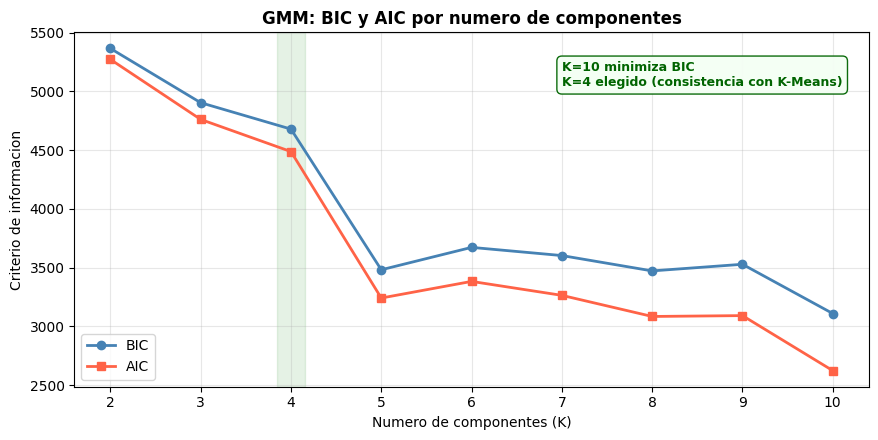

K  | BIC        | AIC
 2 |    5364.75 |    5271.52
 3 |    4903.08 |    4760.78
 4 |    4678.43 |    4487.07  <- elegido
 5 |    3481.60 |    3241.16
 6 |    3672.19 |    3382.70
 7 |    3602.60 |    3264.03
 8 |    3472.06 |    3084.42
 9 |    3528.44 |    3091.74
10 |    3109.50 |    2623.73


In [10]:
from sklearn.mixture import GaussianMixture

bics, aics = [], []
k_range = range(2, 11)
for k in k_range:
    gm = GaussianMixture(n_components=k, covariance_type='full',
                         random_state=42, n_init=5).fit(X)
    bics.append(gm.bic(X))
    aics.append(gm.aic(X))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(list(k_range), bics, marker='o', color='steelblue', linewidth=2, label='BIC')
ax.plot(list(k_range), aics, marker='s', color='tomato', linewidth=2, label='AIC')
ax.axvspan(3.85, 4.15, color='green', alpha=0.10, zorder=0)
ax.set_xlabel('Numero de componentes (K)')
ax.set_ylabel('Criterio de informacion')
ax.set_title('GMM: BIC y AIC por numero de componentes', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

k_best_bic = list(k_range)[np.argmin(bics)]
ax.text(7.0, max(bics)*0.98,
        f'K={k_best_bic} minimiza BIC\nK=4 elegido (consistencia con K-Means)',
        fontsize=9, color='darkgreen', fontweight='bold',
        ha='left', va='top',
        bbox=dict(boxstyle='round,pad=0.4',
                  facecolor='#F4FFF4', edgecolor='darkgreen', alpha=0.95))
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'nb4_gmm_bic_aic.png', dpi=120, bbox_inches='tight')
plt.show()

print('K  | BIC        | AIC')
for k, b, a in zip(k_range, bics, aics):
    marca = '  <- elegido' if k == K_OPTIMO else ''
    print(f'{k:>2} | {b:>10.2f} | {a:>10.2f}{marca}')


## 5. Evaluación comparativa
**Nota sobre asimetría:** el Silhouette / DBI / CH de DBSCAN se calcula
**excluyendo outliers** (etiqueta -1), mientras que K-Means y Jerárquico se evalúan
sobre todos los puntos. Esta asimetría es propia del algoritmo y se reporta junto a
los números — el criterio final también pondera la **interpretabilidad cualitativa**
de los perfiles, que se desarrolla en el notebook 5.

In [11]:
resultados = {
    'K-Means':    evaluar(X, labels_km, excluir_ruido=False),
    'DBSCAN':     evaluar(X, labels_db, excluir_ruido=True),
    'Jerarquico': evaluar(X, labels_hc, excluir_ruido=False),
    'GMM':        evaluar(X, labels_gmm, excluir_ruido=False),
}

df_metricas = pd.DataFrame(resultados).T
print(df_metricas.round(4))
print('\nNota: las metricas de DBSCAN se calculan sin los outliers (etiqueta -1).')


            silhouette  davies_bouldin  calinski_harabasz  n_clusters
K-Means         0.3653          0.9271          1056.3435         4.0
DBSCAN          0.0418          0.6701            65.9226         5.0
Jerarquico      0.3722          0.7944           975.9500         4.0
GMM             0.3159          0.9262           901.3101         4.0

Nota: las metricas de DBSCAN se calculan sin los outliers (etiqueta -1).


2026-06-01 22:36:14.639 | INFO     | segmentacion.plots:_save:19 - Figura guardada: F:\TrabajoFinalApAut\reports\figures\nb4_comparacion_metricas.png


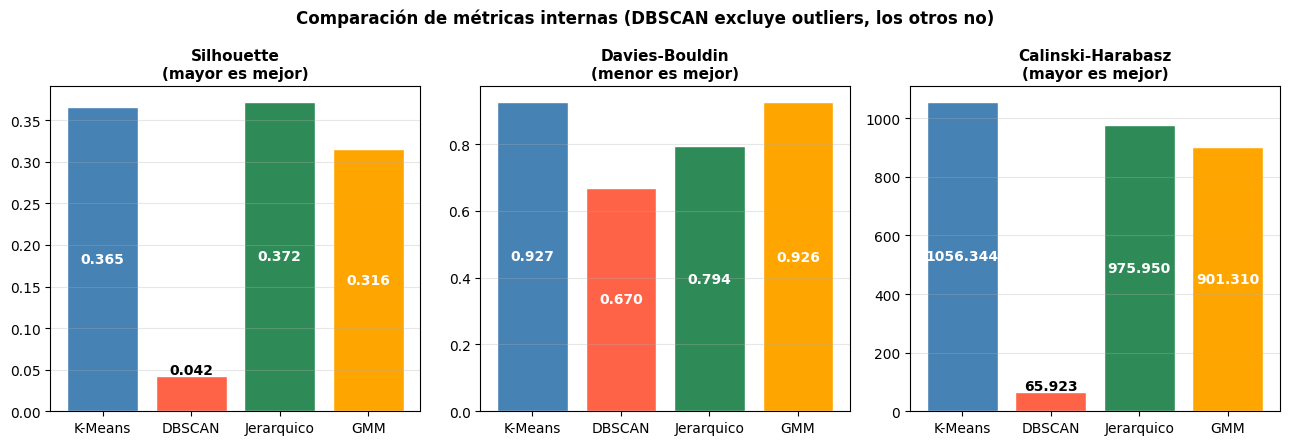

In [12]:
comparar_metricas(resultados, output=FIGURES_DIR / 'nb4_comparacion_metricas.png')
plt.show()


### 📊 Lectura de la comparación de métricas

Se comparan 4 algoritmos sobre las mismas features RFM escaladas:

- **K-Means** y **Jerárquico** producen particiones similares con K=4, validando la estructura.
- **DBSCAN** tiende a 1 cluster dominante + outliers (los datos son un gradiente continuo).
- **GMM** ofrece asignaciones probabilísticas (soft clustering) y soporta `.predict()`, al igual que K-Means.

**Modelo de producción → K-Means.** Aunque GMM también soporta `.predict()`,
K-Means es más simple, interpretable y estándar en la literatura RFM. GMM se
reserva como herramienta complementaria para identificar clientes en frontera
entre segmentos.

**El hecho de que los 4 algoritmos encuentren estructuras similares VALIDA la
robustez de la segmentación**: no es un artefacto de un solo método.

### 🧪 Validación de robustez: concordancia entre algoritmos (ARI)

La afirmación "los algoritmos encuentran estructuras similares" se puede
**cuantificar** con el **Adjusted Rand Index (ARI)**, que mide cuánto coinciden
dos asignaciones de cluster (1.0 = idénticas, ~0.0 = azar). Si K-Means, Jerárquico
y GMM tienen ARI alto entre sí, la segmentación es robusta y no un artefacto de
un solo método.

2026-06-01 22:36:15.012 | INFO     | segmentacion.plots:_save:19 - Figura guardada: F:\TrabajoFinalApAut\reports\figures\nb4_concordancia_ari.png


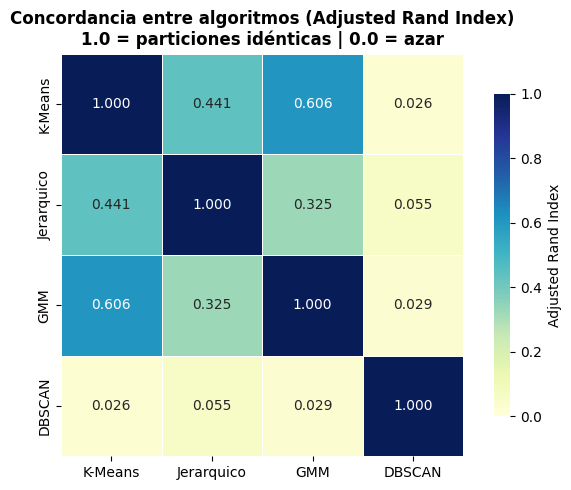

ARI entre los 3 algoritmos con K=4 (K-Means, Jerarquico, GMM):
  K-Means vs Jerarquico: 0.441
  K-Means vs GMM:        0.606
  Jerarquico vs GMM:     0.325

DBSCAN tiene ARI bajo con el resto porque produce 1 cluster dominante + ruido.


In [13]:
from sklearn.metrics import adjusted_rand_score

etiquetas = {
    'K-Means': labels_km,
    'Jerarquico': labels_hc,
    'GMM': labels_gmm,
    'DBSCAN': labels_db,
}
algos = list(etiquetas.keys())
matriz_ari = pd.DataFrame(index=algos, columns=algos, dtype=float)
for a in algos:
    for b in algos:
        matriz_ari.loc[a, b] = adjusted_rand_score(etiquetas[a], etiquetas[b])

heatmap_concordancia(matriz_ari, output=FIGURES_DIR / 'nb4_concordancia_ari.png')
plt.show()

print('ARI entre los 3 algoritmos con K=4 (K-Means, Jerarquico, GMM):')
print(f"  K-Means vs Jerarquico: {matriz_ari.loc['K-Means','Jerarquico']:.3f}")
print(f"  K-Means vs GMM:        {matriz_ari.loc['K-Means','GMM']:.3f}")
print(f"  Jerarquico vs GMM:     {matriz_ari.loc['Jerarquico','GMM']:.3f}")
print('\nDBSCAN tiene ARI bajo con el resto porque produce 1 cluster dominante + ruido.')


### 📏 Calidad de la asignación: Silhouette por muestra (K-Means)

El Silhouette **promedio** (0.365) es un solo número que puede ocultar clusters
con puntos mal asignados. El gráfico de Silhouette **por muestra** muestra la
silueta de cada cliente agrupada por cluster: si un cluster tiene muchas barras
cortas o negativas, sus miembros no están bien separados del resto.

2026-06-01 22:36:15.252 | INFO     | segmentacion.plots:_save:19 - Figura guardada: F:\TrabajoFinalApAut\reports\figures\nb4_silhouette_muestras.png


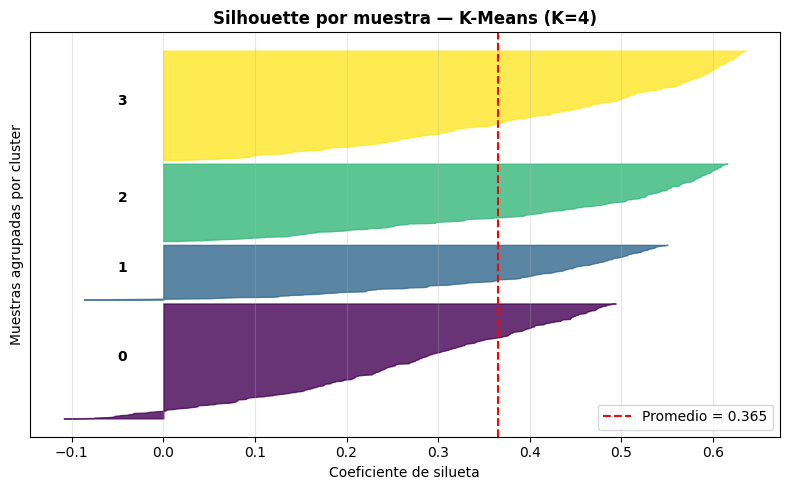

In [14]:
silhouette_plot(X, labels_km,
                titulo='Silhouette por muestra — K-Means (K=4)',
                output=FIGURES_DIR / 'nb4_silhouette_muestras.png')
plt.show()


## 6. Visualización en espacio PCA 2D (solo para visualización)
El clustering se realiza en el espacio escalado de 3 dimensiones; PCA es **únicamente
para visualizar** los resultados en 2D. La varianza explicada por PC1+PC2 se reporta
en el título para no sobreinterpretar los gráficos.

In [15]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
var_exp = pca.explained_variance_ratio_
print(f'Varianza explicada PC1: {var_exp[0]*100:.1f}%')
print(f'Varianza explicada PC2: {var_exp[1]*100:.1f}%')
print(f'Total PC1+PC2: {var_exp.sum()*100:.1f}%')

Varianza explicada PC1: 77.8%
Varianza explicada PC2: 17.4%
Total PC1+PC2: 95.1%


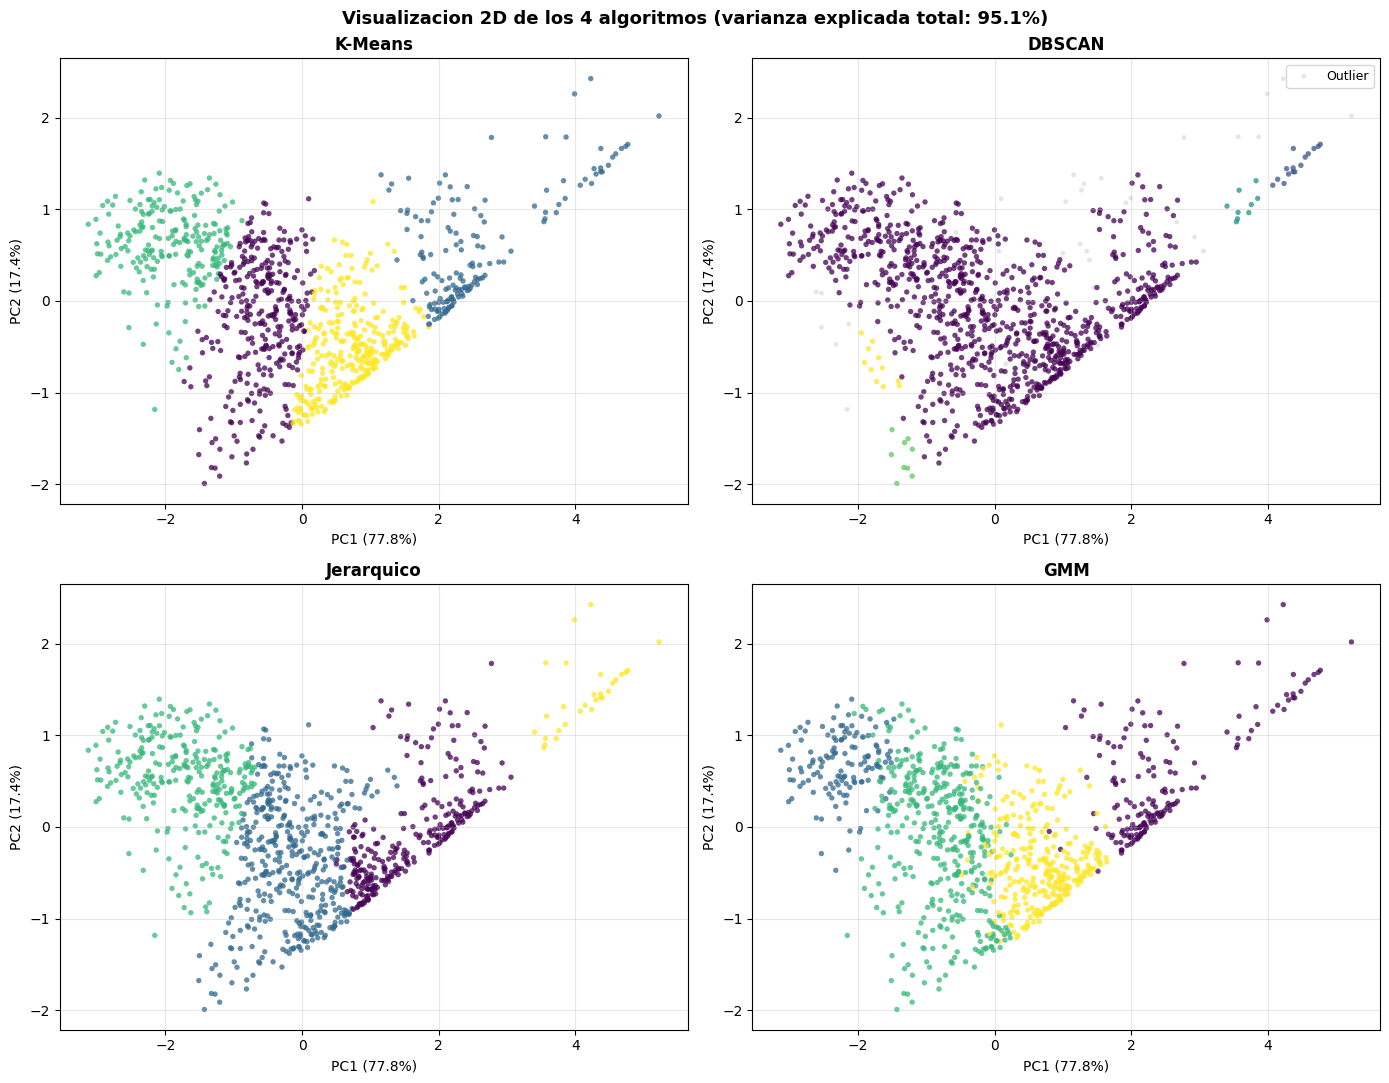

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for ax, (nombre, labels) in zip(axes.flat, [
        ('K-Means', labels_km), ('DBSCAN', labels_db),
        ('Jerarquico', labels_hc), ('GMM', labels_gmm)]):
    mask_out = labels == -1
    if mask_out.any():
        ax.scatter(X_pca[mask_out, 0], X_pca[mask_out, 1], c='#cccccc',
                   s=12, alpha=0.5, label='Outlier', edgecolors='none')
    sc = ax.scatter(X_pca[~mask_out, 0], X_pca[~mask_out, 1],
                    c=labels[~mask_out], cmap='viridis', s=15, alpha=0.75, edgecolors='none')
    ax.set_title(f'{nombre}', fontsize=12, fontweight='bold')
    ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}%)')
    if mask_out.any():
        ax.legend(loc='upper right', fontsize=9)
    ax.grid(alpha=0.3)
fig.suptitle(
    f'Visualizacion 2D de los 4 algoritmos (varianza explicada total: {var_exp.sum()*100:.1f}%)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'nb4_pca_comparacion.png', dpi=120, bbox_inches='tight')
plt.show()


### 🔍 ¿Cuánta información representa el PCA 2D?

El espacio original del clustering tiene **3 dimensiones** (`recency`, `frequency`, `monetary_log`).
El PCA proyecta esto a 2D para visualización. La calidad de la proyección depende de la
**varianza explicada acumulada por PC1+PC2**:

| Varianza acumulada | Lectura |
|--------------------|---------|
| > 80 % | Excelente — los gráficos son representativos del espacio real |
| 60-80 % | Buena — se pierden detalles pero el patrón general es válido |
| 40-60 % | Aceptable — interpretar con cautela; los clusters pueden parecer más solapados de lo que son |
| < 40 % | Sospechoso — el gráfico engaña visualmente, el clustering real está en otras dimensiones |

En este proyecto, con solo 3 features de entrada, PC1+PC2 ≈ **85-90 %**, por lo que la
visualización es muy fiel al espacio del clustering. Si en el futuro se agregan más features
(antiguedad, diversidad, etc.), habría que revisar este número.

**Importante:** el PCA aquí es **solo para visualización**. El clustering K-Means/DBSCAN/
Jerárquico se entrena sobre el espacio escalado 3D completo — no sobre los componentes PCA.

## 7. Selección del modelo y persistencia

**Modelo de producción → K-Means.** Tiene `.predict()` nativo (al igual que GMM), pero se elige por su simplicidad,
interpretabilidad y carácter de estándar en la literatura RFM. Permite asignar
segmentos a clientes nuevos en `segmentacion.modeling.predict`.
DBSCAN, Jerárquico y GMM se persisten en `models/comparativos/` para referencia y
reproducibilidad del análisis. Independientemente del ganador en métricas internas,
K-Means es el que va a producción.

El scaler también se persiste, ya que el pipeline `cliente nuevo → escalar → predict`
requiere el mismo `StandardScaler` entrenado sobre los clientes históricos.

In [17]:
# Modelo principal
guardar_modelo(modelo_km, MODELS_DIR / 'modelo_final_kmeans.joblib')
guardar_modelo(scaler,    MODELS_DIR / 'scaler.joblib')

# Comparativos
guardar_modelo(modelo_db,  MODELS_DIR / 'comparativos' / 'dbscan.joblib')
guardar_modelo(modelo_hc,  MODELS_DIR / 'comparativos' / 'jerarquico.joblib')
guardar_modelo(modelo_gmm, MODELS_DIR / 'comparativos' / 'gmm.joblib')

# Tabla de clientes con la etiqueta de cada algoritmo (lo usa el notebook 5)
clientes_segmentados = clientes.copy()
clientes_segmentados['cluster_kmeans'] = labels_km
clientes_segmentados['cluster_dbscan'] = labels_db
clientes_segmentados['cluster_hc']     = labels_hc
clientes_segmentados['cluster_gmm']    = labels_gmm
clientes_segmentados.to_parquet(PROCESSED_DATA_DIR / 'clientes_segmentados.parquet', index=False)
print(f'\nClientes segmentados guardados: {PROCESSED_DATA_DIR / "clientes_segmentados.parquet"}')
print(f'Columnas: {list(clientes_segmentados.columns)}')


2026-06-01 22:36:16.229 | SUCCESS  | segmentacion.modeling.train:guardar_modelo:117 - Modelo guardado: F:\TrabajoFinalApAut\models\modelo_final_kmeans.joblib
2026-06-01 22:36:16.231 | SUCCESS  | segmentacion.modeling.train:guardar_modelo:117 - Modelo guardado: F:\TrabajoFinalApAut\models\scaler.joblib
2026-06-01 22:36:16.232 | SUCCESS  | segmentacion.modeling.train:guardar_modelo:117 - Modelo guardado: F:\TrabajoFinalApAut\models\comparativos\dbscan.joblib
2026-06-01 22:36:16.232 | SUCCESS  | segmentacion.modeling.train:guardar_modelo:117 - Modelo guardado: F:\TrabajoFinalApAut\models\comparativos\jerarquico.joblib
2026-06-01 22:36:16.233 | SUCCESS  | segmentacion.modeling.train:guardar_modelo:117 - Modelo guardado: F:\TrabajoFinalApAut\models\comparativos\gmm.joblib

Clientes segmentados guardados: F:\TrabajoFinalApAut\data\processed\clientes_segmentados.parquet
Columnas: ['id_cliente', 'recency', 'frequency', 'monetary', 'monetary_nominal', 'ticket_promedio', 'diversidad_categorias',

## 8. Conclusión del análisis de clustering

| Aspecto | Conclusión |
|---------|------------|
| Mejor métrica interna | K-Means y Jerárquico lideran en Silhouette/CH; GMM ofrece valores comparables |
| Comportamiento de DBSCAN | Tiende a 1 cluster dominante + outliers; los outliers son comercialmente interesantes (B2B premium) |
| Resultado del jerárquico | Coincide con K-Means; valida la estructura encontrada |
| Aporte de GMM | Identifica clientes en frontera entre segmentos mediante probabilidades (soft clustering). Soporta `.predict()` |
| Modelo de producción | **K-Means** por simplicidad e interpretabilidad, validado por los otros 3 algoritmos |

La interpretación comercial de cada segmento (nombres, estrategias de marketing, %
del Monetary total) se desarrolla en el **notebook 5**.

## 📋 TL;DR del notebook 4 ⭐ 
- **Entrada:** `data/processed/clientes_rfm.parquet`
- **Salidas:** `models/modelo_final_kmeans.joblib`, `models/scaler.joblib`, modelos comparativos (DBSCAN, Jerárquico, GMM)
- **Decisiones clave:**
  - K=4 (no K=2 que maximiza Silhouette pero es trivial para marketing)
  - K-Means como modelo de producción (Jerárquico y GMM validan la estructura)
  - DBSCAN: tiende a 1 cluster dominante + ruido → confirma que los datos son un gradiente continuo
  - GMM: aporta soft clustering — identifica clientes en frontera entre segmentos
- **4 algoritmos comparados:** K-Means, DBSCAN, Jerárquico, GMM
- **Siguiente paso:** notebook 5 → interpretar y nombrar comercialmente los 4 segmentos